# Build the analysis dataset — load · clean · merge

_Merged notebook — sections below keep their own audit-log step names._

---
<a id='nb01'></a>
# 1 · [nb01] 01 · Load data — structural extraction of the raw government spreadsheets
---

# 01 · Load data — structural extraction of the raw government spreadsheets

**Goal:** turn every presentation-formatted sheet into a tidy *long* table
**without any cleaning, filtering, imputation, or window restriction**. Missing-
value tokens (`---`, `///`, `-`, blank) are preserved verbatim in `raw_value`;
numeric coercion and missing-value classification happen in the `02_clean`
section below.

The parsers live in **`src/loaders.py`** (pure functions). Each raw table is
**cached** to `data/processed/01_loaded/<name>.parquet` and reused on a re-run
unless the source file or a parser in `src/` changed (set `FORCE_RELOAD = True`
to always rebuild).

**Inputs** (read-only): the six files in `data/raw/`.
**Outputs** → `data/processed/01_loaded/`: one parquet per source table.
Each workbook's structure (merged cells, header bands, missing-value tokens,
the two columns both labelled "Total") is handled by the parsers in
`src/loaders.py`.

In [1]:
import sys
from pathlib import Path

import pandas as pd

SRC = Path.cwd() / "src"
sys.path.insert(0, str(SRC))
import config as C
from common import AuditLog
import loaders as LD

LOG = AuditLog("01_load")
C.P_LOADED_DIR.mkdir(parents=True, exist_ok=True)
print("project root :", C.ROOT)
print("raw inputs   :", *[p.name for p in sorted(C.DATA_RAW.iterdir())])

# --- incremental cache -------------------------------------------------------
FORCE_RELOAD = False
_SRC_MTIME = max(f.stat().st_mtime for f in SRC.glob("*.py"))


def cached_load(name, source_path, builder):
    """Reuse data/processed/01_loaded/<name>.parquet unless FORCE_RELOAD, the
    source file, or any src/*.py parser is newer than it."""
    out = C.P_LOADED_DIR / f"{name}.parquet"
    if (not FORCE_RELOAD and out.exists()
            and out.stat().st_mtime >= source_path.stat().st_mtime
            and out.stat().st_mtime >= _SRC_MTIME):
        df = pd.read_parquet(out)
        LOG.log("cached", f"{name}.parquet", len(df), "reused (source & parsers unchanged)")
        return df
    df = builder()
    for tgt, raw in df.attrs.get("unmapped", []):
        LOG.log("unmapped_header", tgt, detail=repr(raw))
    df.to_parquet(out)
    LOG.log("parsed", f"{source_path.name} -> {name}", len(df),
            f"{df['date'].min():%Y-%m}..{df['date'].max():%Y-%m}, "
            f"{df['hotel_category'].nunique() if 'hotel_category' in df else df['region'].nunique()} "
            f"{'categories' if 'hotel_category' in df else 'regions'}")
    return df

project root : /Users/jaganathapandiyan/Desktop/Python/argentina-hotels
raw inputs   : .DS_Store Ehoba_02a_0811.xlsx Ehoba_03a_0811.xlsx Ehoba_04_0811.xlsx Ehoba_1_ano.xlsx Ehoba_VA_0811.xlsx India_CPI airbnb sh_ipc_08_26.xls


## Monthly EHOBA sheets  (rate · room-occ · bed-occ · travellers)

Layout: row 1 title, a 2–3 row header band, then repeating `[year row]
[12 month-name rows]`. `src/loaders.load_monthly_ehoba` reads the category
names from the header row and uses the hotel / para-hotel band row to
disambiguate the two columns both labelled "Total".

In [2]:
room = cached_load("room_occupancy", C.F_ROOM_OCC, lambda: LD.load_monthly_ehoba(
    C.F_ROOM_OCC, "Ehoba_02a_0811", header_row=4, band_row=3, first_data_row=5))
bed = cached_load("bed_occupancy", C.F_BED_OCC, lambda: LD.load_monthly_ehoba(
    C.F_BED_OCC, "Ehoba_04_0811", header_row=4, band_row=3, first_data_row=5))
rate = cached_load("average_rate", C.F_RATE, lambda: LD.load_monthly_ehoba(
    C.F_RATE, "Ehoba_03a_0811", header_row=4, band_row=3, first_data_row=5))
trav = cached_load("travelers", C.F_TRAVELERS, lambda: LD.load_monthly_ehoba(
    C.F_TRAVELERS, "Ehoba_VA_0811", header_row=3, band_row=None, first_data_row=4,
    total_is_parahotel_band=False))
rate.head()

  [01_load] cached                 room_occupancy.parquet               2210  reused (source & parsers unchanged)
  [01_load] cached                 bed_occupancy.parquet                2210  reused (source & parsers unchanged)
  [01_load] cached                 average_rate.parquet                 1768  reused (source & parsers unchanged)
  [01_load] cached                 travelers.parquet                     966  reused (source & parsers unchanged)


,date,hotel_category,raw_value,cell_value,cell_is_numeric,provisional,src_sheet,src_row,src_col
0,2008-01-01,stars_1_2,97.17045454545455,97.170455,True,False,Ehoba_03a_0811,6,2
1,2008-01-01,stars_3,162.31034482758622,162.310345,True,False,Ehoba_03a_0811,6,3
2,2008-01-01,stars_4,230.31147540983608,230.311475,True,False,Ehoba_03a_0811,6,4
3,2008-01-01,stars_5,581.9130434782609,581.913043,True,False,Ehoba_03a_0811,6,5
4,2008-01-01,apart,202,202.000000,True,False,Ehoba_03a_0811,6,6


## Capacity workbook (`Ehoba_1_ano.xlsx`)

One sheet per year; 1–4 quarterly snapshot blocks (Mar / Jun / Jul / Sep / Dec).
Metrics: establishments, `Habitaciones o unidades disponibles` (room-nights),
`Plazas disponibles` (bed-nights). The 2008 sheet uses the older EOH taxonomy →
tagged `source_taxonomy = "2008_eoh"`.

In [3]:
cap = cached_load("capacity", C.F_CAPACITY, lambda: LD.load_capacity(C.F_CAPACITY))
cap.groupby(cap.date.dt.year).date.apply(lambda s: sorted(s.dt.month.unique()))

  [01_load] cached                 capacity.parquet                     1830  reused (source & parsers unchanged)


date
2008          [3, 12]
2009          [3, 12]
2010          [3, 12]
2011       [3, 7, 12]
2012       [3, 7, 12]
2013       [3, 7, 12]
2014       [3, 7, 12]
2015       [3, 7, 12]
2016    [3, 6, 9, 12]
2017    [3, 6, 9, 12]
2018    [3, 6, 9, 12]
2019    [3, 6, 9, 12]
2020    [3, 6, 9, 12]
2021    [3, 6, 9, 12]
2022    [3, 6, 9, 12]
2023    [3, 6, 9, 12]
2024    [3, 6, 9, 12]
2025    [3, 6, 9, 12]
2026              [3]
Name: date, dtype: object

## CPI workbook (`sh_ipc_08_26.xls`) — INDEC IPC, base dic-2016 = 100

Legacy `.xls` → `xlrd`. Periods run across columns as Excel serials; region
blocks stacked down column A. We keep the index-level sheet, the MoM sheet
(cross-check), and the GBA bridge sheet that extends GBA back to 2016-04.

In [4]:
cpi = cached_load("cpi", C.F_CPI, lambda: LD.load_cpi(C.F_CPI))
cpi[(cpi.src_sheet == "index_national") & (cpi.region == "gba") &
    (cpi.series.str.lower() == "nivel general")].tail(3)

  [01_load] cached                 cpi.parquet                         29448  reused (source & parsers unchanged)


,src_sheet,region,series,date,value
2201,index_national,gba,Nivel general,2026-05-01,11594.5499
2202,index_national,gba,Nivel general,2026-06-01,11810.9464
2203,index_national,gba,Nivel general,2026-07-01,12078.7372


## Done — flush the audit log

In [5]:
LOG.log("write", str(C.P_LOADED_DIR.relative_to(C.ROOT)), 6, "parquet files (cached where possible)")
LOG.flush()
print("01_load complete.")

  [01_load] write                  data/processed/01_loaded                6  parquet files (cached where possible)
01_load complete.


---
<a id='nb02'></a>
# 2 · [nb02] 02 · Clean data — coercion, missing-value classification, outlier register
---

# 02 · Clean data — coercion, missing-value classification, outlier register

**No imputation, no row dropping, no window restriction** (that is notebook `03`).
What happens here:

1. Coerce each cell to a float, trusting the *native* numeric value from the
   workbook and only string-parsing genuinely non-numeric cells.
2. Classify every absent value into a `missing_reason`
   (`hostel_room_occ_not_published`, `covid_hole`, `covid_recovery_gap`,
   `provisional_gap`, `series_not_started`, `na_token`, …).
3. Reshape into one long monthly panel `date × hotel_category × variable`,
   a quarterly capacity table, and a monthly CPI table with the two deflators.
4. Build a **flag-only** outlier register (nothing is removed).

**Inputs** `data/processed/01_loaded/*.parquet` →
**Outputs** `02_panel_long.parquet`, `02_capacity_quarterly.parquet`,
`02_cpi_monthly.parquet`, plus `outputs/tables/missing_value_map.csv` and
`outputs/tables/outlier_register.csv`.

In [6]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

SRC = Path.cwd() / "src"
sys.path.insert(0, str(SRC))
import config as C
from common import AuditLog, is_na_token, to_number

LOG = AuditLog("02_clean")
L = C.P_LOADED_DIR
VARLABEL = {"room_occupancy": "room_occupancy", "bed_occupancy": "bed_occupancy",
            "average_rate": "average_rate", "travelers": "travelers"}

## Numeric coercion + missing-value reason

`classify_missing` runs only on rows whose numeric value is `NaN`, so a
non-empty `missing_reason` is by construction mutually exclusive with a present
value. COVID windows are the dates locked in `config.py` (`2020-03…2021-12`
hard hole, `2022` degraded recovery).

In [7]:
def classify_missing(row):
    if not np.isnan(row["value"]):
        return ""
    d, var, cat = row["date"], row["variable"], row["hotel_category"]
    tok = str(row["raw_value"]).strip().lower()
    if var == "room_occupancy" and cat == "hostel" and tok in {"---", "--", "-"}:
        return "hostel_room_occ_not_published"
    if var == "travelers" and cat in {"hostel", "otros_resto", "total_parahoteleros"}:
        return "not_in_series_scope"
    if var == "travelers" and d < pd.Timestamp(2013, 1, 1):
        return "series_not_started"
    if C.COVID_HOLE_START <= d.strftime("%Y-%m-%d") <= C.COVID_HOLE_END:
        return "covid_hole"
    if C.COVID_RECOVERY_START <= d.strftime("%Y-%m-%d") <= C.COVID_RECOVERY_END:
        return "covid_recovery_gap"
    if d >= pd.Timestamp(2025, 12, 1):
        return "provisional_gap"
    if is_na_token(row["raw_value"]):
        return "na_token"
    return "unparseable"


def load_and_coerce(name):
    df = pd.read_parquet(L / f"{name}.parquet").copy()
    df["variable"] = VARLABEL[name]
    parsed = df["raw_value"].where(~df["cell_is_numeric"]).map(
        lambda v: to_number(v) if isinstance(v, str) else (float("nan"), False, False))
    df["value"] = np.where(df["cell_is_numeric"], df["cell_value"],
                           [p[0] for p in parsed])
    df["_unparseable"] = [p[2] for p in parsed]
    if int(df["_unparseable"].sum()):
        ex = df.loc[df["_unparseable"], "raw_value"].value_counts().head(5).to_dict()
        LOG.log("unparseable_cells", name, int(df["_unparseable"].sum()), str(ex))
    df["missing_reason"] = df.apply(classify_missing, axis=1)
    LOG.log("coerced", name, len(df),
            f"{df['value'].notna().sum()} numeric / {df['value'].isna().sum()} NaN")
    return df[["date", "hotel_category", "variable", "value", "raw_value",
               "missing_reason", "provisional", "src_sheet", "src_row", "src_col"]]

In [8]:
parts = [load_and_coerce(n) for n in
         ["average_rate", "room_occupancy", "bed_occupancy", "travelers"]]
panel = pd.concat(parts, ignore_index=True).sort_values(
    ["variable", "hotel_category", "date"]).reset_index(drop=True)

bad_occ = panel[(panel.variable.str.contains("occupancy")) & panel.value.notna() &
                ((panel.value < 0) | (panel.value > 100))]
bad_rate = panel[(panel.variable == "average_rate") & panel.value.notna() &
                 (panel.value <= 0)]
LOG.log("range_check_occupancy", "0..100", len(bad_occ),
        "ok" if not len(bad_occ) else "OUT OF RANGE")
LOG.log("range_check_rate", ">0", len(bad_rate),
        "ok" if not len(bad_rate) else "NON-POSITIVE")
assert len(bad_occ) == 0 and len(bad_rate) == 0, "range check failed"

mm = (panel.groupby(["variable", "missing_reason"]).size().rename("n")
      .reset_index().sort_values(["variable", "missing_reason"]))
mm.to_csv(C.OUT_TAB / "missing_value_map.csv", index=False)
mm

  [02_clean] coerced                average_rate                         1768  1540 numeric / 228 NaN
  [02_clean] coerced                room_occupancy                       2210  1794 numeric / 416 NaN


  [02_clean] coerced                bed_occupancy                        2210  1984 numeric / 226 NaN
  [02_clean] coerced                travelers                             966  822 numeric / 144 NaN
  [02_clean] range_check_occupancy  0..100                                  0  ok
  [02_clean] range_check_rate       >0                                      0  ok


,variable,missing_reason,n
0,average_rate,,1540
1,average_rate,covid_hole,176
2,average_rate,covid_recovery_gap,36
3,average_rate,provisional_gap,16
4,bed_occupancy,,1984
5,bed_occupancy,covid_hole,190
6,bed_occupancy,covid_recovery_gap,36
7,room_occupancy,,1794
8,room_occupancy,covid_hole,170
9,room_occupancy,covid_recovery_gap,36


## Capacity → quarterly, wide by metric

In [9]:
cap = pd.read_parquet(L / "capacity.parquet").copy()
cap["value"] = np.where(cap["cell_is_numeric"], cap["cell_value"],
                        cap["raw_value"].map(lambda v: to_number(v)[0]))
cap_w = (cap.pivot_table(index=["date", "snapshot_month", "hotel_category",
                                "source_taxonomy"],
                         columns="metric", values="value", aggfunc="first")
         .reset_index())
cap_w.columns.name = None
for _, r in cap_w[(cap_w.establishments.notna()) &
                  (cap_w.establishments % 1 != 0)].iterrows():
    LOG.log("noninteger_establishments", f"{r['date']:%Y-%m} {r['hotel_category']}",
            round(r["establishments"], 2), "kept, flagged (source-imputed)")
cap_w["is_provisional_2023plus"] = cap_w["date"].dt.year >= 2023
cap_w = cap_w.sort_values(["hotel_category", "date"]).reset_index(drop=True)
LOG.log("capacity_wide", "02_capacity_quarterly", len(cap_w),
        f"{cap_w.date.min():%Y-%m}..{cap_w.date.max():%Y-%m}")
cap_w.tail(4)

  [02_clean] noninteger_establishments 2020-12 total_hoteleros            169.81  kept, flagged (source-imputed)
  [02_clean] capacity_wide          02_capacity_quarterly                 530  2008-03..2026-03


,date,snapshot_month,hotel_category,source_taxonomy,available_bed_nights,available_room_nights,establishments,is_provisional_2023plus
526,2025-06-01,6,total_parahoteleros,ehoba,156660.0,60270.0,61.0,True
527,2025-09-01,9,total_parahoteleros,ehoba,156480.0,60540.0,61.0,True
528,2025-12-01,12,total_parahoteleros,ehoba,166098.0,63736.0,61.0,True
529,2026-03-01,3,total_parahoteleros,ehoba,152954.0,58683.0,68.0,True


## CPI monthly — build the two deflators + INDEC MoM cross-check

* `cpi_gba` = GBA bridge (2016-04…2016-11) spliced onto the GBA block of the
  index sheet (2016-12…). Both are already on the dic-2016 = 100 base, so this
  is a level continuation — verified by the overlap check at 2016-12.
* `cpi_nac` = national headline index (`Nivel general`, 2016-12…).
* `cpi_resthot_*` = the "Restaurants & hotels" (`Restaurantes y hoteles`) COICOP
  division (context only — a consumer-price index, **not** a hotel cost index).
* Cross-check: MoM recomputed from `cpi_gba` levels vs INDEC's published MoM.

In [10]:
cpi = pd.read_parquet(L / "cpi.parquet").copy()
cpi["s"] = cpi["series"].str.strip().str.lower()


def pick(sheet, region, s):
    m = cpi[(cpi.src_sheet == sheet) & (cpi.region == region) & (cpi.s == s)]
    return m.set_index("date")["value"].sort_index()


idx_gba = pick("index_national", "gba", "nivel general")
bridge = pick("gba_bridge", "gba", "nivel general")
idx_nac = pick("index_national", "total_nacional", "nivel general")
mom_gba_pub = pick("mom_national", "gba", "nivel general")
mom_nac_pub = pick("mom_national", "total_nacional", "nivel general")

ov = bridge.index.intersection(idx_gba.index)
LOG.log("cpi_splice_check", "gba bridge vs index @ overlap",
        f"{(bridge[ov] - idx_gba[ov]).abs().max():.4f}",
        "max abs index-point diff (expect ~0 at 2016-12)")

cpi_gba = pd.concat([bridge[bridge.index < idx_gba.index.min()], idx_gba]).sort_index()
out = pd.DataFrame({"cpi_gba": cpi_gba})
out["cpi_nac"] = idx_nac
out["cpi_resthot_gba"] = pick("index_national", "gba", "restaurantes y hoteles")
out["cpi_resthot_nac"] = pick("index_national", "total_nacional", "restaurantes y hoteles")
out["indec_mom_gba_pct"] = mom_gba_pub * (100 if mom_gba_pub.abs().median() < 1 else 1)
out["indec_mom_nac_pct"] = mom_nac_pub * (100 if mom_nac_pub.abs().median() < 1 else 1)
out = out.sort_index()
out.index.name = "date"
out = out.reset_index()

chk = out.assign(mom_calc_gba=out["cpi_gba"].pct_change() * 100).dropna(
    subset=["mom_calc_gba", "indec_mom_gba_pct"])
gap = (chk["mom_calc_gba"] - chk["indec_mom_gba_pct"]).abs()
LOG.log("cpi_mom_crosscheck", "calc vs INDEC (GBA)",
        f"max={gap.max():.3f}pp", f"mean={gap.mean():.4f}pp over {len(chk)} months")
LOG.log("cpi_monthly", "02_cpi_monthly", len(out),
        f"{out.date.min():%Y-%m}..{out.date.max():%Y-%m}; "
        f"cpi_nac starts {out.dropna(subset=['cpi_nac']).date.min():%Y-%m}")
out.tail(4)

  [02_clean] cpi_splice_check       gba bridge vs index @ overlap      0.0000  max abs index-point diff (expect ~0 at 2016-12)
  [02_clean] cpi_mom_crosscheck     calc vs INDEC (GBA)              max=0.050pp  mean=0.0245pp over 114 months
  [02_clean] cpi_monthly            02_cpi_monthly                        124  2016-04..2026-07; cpi_nac starts 2016-12


,date,cpi_gba,cpi_nac,cpi_resthot_gba,cpi_resthot_nac,indec_mom_gba_pct,indec_mom_nac_pct
120,2026-04-01,11336.5576,11363.0904,13841.4078,14041.1974,NaN,NaN
121,2026-05-01,11594.5499,11607.3937,14129.9031,14291.4848,2.3,2.1
122,2026-06-01,11810.9464,11826.4103,14294.4029,14524.0788,1.9,1.9
123,2026-07-01,12078.7372,12076.3937,14759.1647,14923.8212,2.3,2.1


## Outlier register (flag only — nothing removed)

Rule: a monthly log-change in `average_rate` bigger than 0.40 that is reversed
the following month (opposite sign, magnitude > 0.25). Captures one-month data
spikes without touching genuine step-changes such as the Dec-2023 devaluation.

In [11]:
recs = []
sub = panel[(panel.variable == "average_rate") & panel.value.notna()]
for cat, g in sub.groupby("hotel_category"):
    g = g.sort_values("date")
    dln = np.log(g.value).diff()
    nxt = dln.shift(-1)
    for d, v, dl, rv in zip(g.date, g.value, dln, nxt):
        if np.isfinite(dl) and abs(dl) > 0.40 and np.isfinite(rv) and \
                np.sign(rv) == -np.sign(dl) and abs(rv) > 0.25:
            recs.append({"variable": "average_rate", "hotel_category": cat,
                         "date": d, "value": round(v, 2),
                         "dln": round(float(dl), 3), "dln_next": round(float(rv), 3),
                         "note": "one-month spike then reversion"})
outliers = pd.DataFrame(recs)
outliers.to_csv(C.OUT_TAB / "outlier_register.csv", index=False)
LOG.log("outlier_register", "outlier_register.csv", len(outliers), "flagged, NOT removed")
outliers

  [02_clean] outlier_register       outlier_register.csv                    1  flagged, NOT removed


,variable,hotel_category,date,value,dln,dln_next,note
0,average_rate,stars_5,2025-08-01,381800.96,0.529,-0.355,one-month spike then reversion


## Write outputs

In [12]:
panel.to_parquet(C.P_PANEL_LONG)
cap_w.to_parquet(C.P_CAPACITY_Q)
out.to_parquet(C.P_CPI_MONTHLY)
LOG.log("write", "data/processed",
        detail="02_panel_long / 02_capacity_quarterly / 02_cpi_monthly")
LOG.flush()
print("02_clean_data complete.")

  [02_clean] write                  data/processed                             02_panel_long / 02_capacity_quarterly / 02_cpi_monthly
02_clean_data complete.


---
<a id='nb03'></a>
# 3 · [nb03] 03 · Merge — build the clean monthly analysis panel
---

# 03 · Merge — build the clean monthly analysis panel

Combines the cleaned long panel, the two CPI deflators, and the quarterly
capacity snapshots into one modelling table, and derives inflation / real-rate /
seasonality / sample-split / revenue-proxy columns.

**Framing (see `REPORT.md` §3):** the project studies *when a Buenos Aires
hotel category should reprice* under inflation. Construction rules:

* **Long-run context** from 2008 (`is_longrun`) is nominal-only. The **main
  analysis sample** is `2018-01…2019-12 + 2022-01…2025-11` (`in_sample`);
  **COVID `2020-01…2021-12`** (`is_covid`) is held out and analysed separately.
  The raw panel loads through 2026-05, but the analysis stops at **2025-11** —
  from 2025-12 the EHOBA rates are provisional and straddle a data gap.
* `real_rate` $= \text{nominal\_rate} / \text{cpi} \times 100$, base
  **dic-2016 = 100**. GBA primary, national as robustness.
* `infl_mom_*_frac` is monthly inflation in **fraction** units
  ($\text{CPI}_t / \text{CPI}_{t-1} - 1$) — the unit the `src/policies.py`
  engine expects.
* A **capacity-weighted composite "Total"** rate is built here because the
  source rate file has no Total column; it is quarterly-anchored and labelled
  `total_composite` (derived, not an official series).
* Capacity is **quarterly** → attached as-of the nearest prior snapshot in
  `*_asof` columns. `revenue_proxy` mixes monthly occupancy with quarterly
  capacity and is labelled a proxy.

**Inputs** `02_panel_long`, `02_cpi_monthly`, `02_capacity_quarterly` →
**Output** `03_analysis_panel.parquet`, `data_dictionary.csv`,
`coverage_by_category.csv`, `outputs/figures/03_*.png`.

In [13]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SRC = Path.cwd() / "src"
sys.path.insert(0, str(SRC))
import config as C
from common import AuditLog

LOG = AuditLog("03_merge")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": C.PLOT_DPI,
                     "axes.grid": True, "grid.alpha": .3, "font.size": 9})

panel = pd.read_parquet(C.P_PANEL_LONG)
cpi = pd.read_parquet(C.P_CPI_MONTHLY)
capq = pd.read_parquet(C.P_CAPACITY_Q)

## 1 · Long → wide (one row per date × hotel_category)

In [14]:
wide = (panel.pivot_table(index=["date", "hotel_category"], columns="variable",
                          values="value", aggfunc="first", dropna=False)
        .reset_index().sort_values(["hotel_category", "date"]))
wide.columns.name = None
for v in ["average_rate", "room_occupancy", "bed_occupancy", "travelers"]:
    if v not in wide:
        wide[v] = np.nan
rr = panel[panel.variable == "average_rate"][["date", "hotel_category", "missing_reason", "provisional"]]
wide = wide.merge(rr, on=["date", "hotel_category"], how="left")
wide = wide.rename(columns={"missing_reason": "rate_missing_reason",
                            "provisional": "rate_provisional"})
LOG.log("pivot", "wide panel", len(wide),
        f"{wide.date.min():%Y-%m}..{wide.date.max():%Y-%m}, {wide.hotel_category.nunique()} categories")

  [03_merge] pivot                  wide panel                           2210  2008-01..2026-05, 10 categories


## 2 · Merge CPI, build inflation (percent AND fraction) & real rates

In [15]:
cpi = cpi.sort_values("date").copy()
for geo in ["gba", "nac"]:
    lvl = cpi[f"cpi_{geo}"]
    cpi[f"infl_mom_{geo}"] = lvl.pct_change() * 100
    cpi[f"infl_mom_{geo}_frac"] = lvl.pct_change()
    cpi[f"infl_yoy_{geo}"] = lvl.pct_change(12) * 100
    for k in (3, 6, 12):
        cpi[f"cum_infl_{geo}_{k}m"] = (lvl / lvl.shift(k) - 1) * 100

wide = wide.merge(cpi, on="date", how="left")
for geo in ["gba", "nac"]:
    wide[f"real_rate_{geo}"] = wide["average_rate"] / wide[f"cpi_{geo}"] * 100
    wide[f"real_resthot_defl_{geo}"] = wide["average_rate"] / wide[f"cpi_resthot_{geo}"] * 100
LOG.log("cpi_merge", "real rates + inflation (pct & frac)",
        int(wide["infl_mom_gba"].notna().sum()))

  [03_merge] cpi_merge              real rates + inflation (pct & frac)     1200  


## 3 · Seasonality, time index, sample-split flags

`in_sample` = 2018-19 + 2022-01…2025-11 (main). `is_covid` = 2020-01…2021-12 (held out).
`is_longrun` = 2008+. `split` $\in \{\text{train},\ \text{valid},\ \text{test},\ \text{none}\}$
(train = 2018-19 + 2022, valid = 2023, test = 2024-01…2025-11; see `REPORT.md` §3.3 / §8).

In [16]:
wide["month"] = wide["date"].dt.month
wide["year"] = wide["date"].dt.year
wide["t"] = (wide["date"] - pd.Timestamp("2018-01-01")).dt.days / 30.44
for m in range(2, 13):
    wide[f"m{m:02d}"] = (wide["month"] == m).astype(int)


def _in_segments(dates, segs):
    m = pd.Series(False, index=dates.index)
    for a, b in segs:
        m |= (dates >= pd.Timestamp(a)) & (dates <= pd.Timestamp(b))
    return m.astype(int)


wide["is_longrun"] = (wide["date"] >= C.LONGRUN_START).astype(int)
wide["is_covid"] = ((wide["date"] >= C.COVID_START) & (wide["date"] <= C.COVID_END)).astype(int)
wide["in_sample"] = _in_segments(wide["date"], C.ANALYSIS_SEGMENTS)
wide["covid_hole"] = ((wide["date"] >= C.COVID_HOLE_START) &
                      (wide["date"] <= C.COVID_HOLE_END)).astype(int)
wide["covid_any"] = wide["is_covid"]                       # back-compat alias
wide["in_window"] = ((wide["date"] >= C.WINDOW_START) &
                     (wide["date"] <= C.WINDOW_END)).astype(int)   # back-compat

split = np.where(_in_segments(wide["date"], C.TRAIN_SEGMENTS).astype(bool), "train",
        np.where(_in_segments(wide["date"], [C.VALID_SEGMENT]).astype(bool), "valid",
        np.where(_in_segments(wide["date"], [C.TEST_SEGMENT]).astype(bool), "test", "none")))
wide["split"] = split
LOG.log("sample_flags", "in_sample / covid / split",
        f"{int(wide.in_sample.sum())} / {int(wide.is_covid.sum())} rows",
        f"train/valid/test months = "
        f"{wide.query('hotel_category==\"stars_4\"').split.value_counts().to_dict()}")

  [03_merge] sample_flags           in_sample / covid / split        710 / 240 rows  train/valid/test months = {'none': 150, 'train': 36, 'test': 23, 'valid': 12}


## 4 · Capacity as-of nearest prior quarterly snapshot

In [17]:
capq2 = capq[capq["source_taxonomy"] == "ehoba"].sort_values("date").copy()
pieces = []
for cat, g in wide.sort_values("date").groupby("hotel_category"):
    src = capq2[capq2["hotel_category"] == cat][
        ["date", "establishments", "available_room_nights", "available_bed_nights"]
    ].rename(columns={"date": "capacity_asof_date",
                      "establishments": "establishments_asof",
                      "available_room_nights": "available_room_nights_asof",
                      "available_bed_nights": "available_bed_nights_asof"})
    if src.empty:
        g = g.assign(capacity_asof_date=pd.NaT, establishments_asof=np.nan,
                     available_room_nights_asof=np.nan, available_bed_nights_asof=np.nan)
    else:
        g = pd.merge_asof(g, src, left_on="date", right_on="capacity_asof_date",
                          direction="backward")
    pieces.append(g)
wide = pd.concat(pieces, ignore_index=True)
wide["capacity_asof_lag_months"] = (
    (wide["date"].dt.year - wide["capacity_asof_date"].dt.year) * 12 +
    (wide["date"].dt.month - wide["capacity_asof_date"].dt.month))
LOG.log("capacity_asof", "merge_asof backward",
        int(wide["available_room_nights_asof"].notna().sum()),
        f"median lag {wide['capacity_asof_lag_months'].median():.0f} mo")

  [03_merge] capacity_asof          merge_asof backward                  2031  median lag 1 mo


## 5 · Capacity-weighted composite "Total" rate

The source rate file has **no Total column**. We build one: for each month,

$$\text{rate\_total\_composite}
= \frac{\sum_c w_c \cdot \text{rate}_c}{\sum_c w_c}$$

over the six hotel-sector categories (1-2★ … boutique), with weights
$w_c = \text{available\_room\_nights\_asof}$ (equal weights if all as-of capacity
is missing that month). Room occupancy for the composite uses the **published**
`total_hoteleros` series where available (a genuine figure), else the
capacity-weighted mean. Flagged `total_composite`.

In [18]:
HOTELERO = ["stars_1_2", "stars_3", "stars_4", "stars_5", "apart", "boutique"]
sub = wide[wide.hotel_category.isin(HOTELERO)].copy()
sub["w"] = sub["available_room_nights_asof"].where(lambda s: s > 0)
rows = []
for dt, g in sub.groupby("date"):
    gg = g.dropna(subset=["average_rate"])
    if gg.empty:
        continue
    w = gg["w"]
    w = w if w.notna().any() else pd.Series(1.0, index=gg.index)
    w = w.fillna(w[w.notna()].mean() if w.notna().any() else 1.0)
    rate = float((gg["average_rate"] * w).sum() / w.sum())
    occ_w = float((gg["room_occupancy"] * w).sum() / w.sum()) if gg["room_occupancy"].notna().any() else np.nan
    rows.append({"date": dt, "hotel_category": C.COMPOSITE_TOTAL,
                 "average_rate": rate, "room_occupancy_wtd": occ_w})
comp = pd.DataFrame(rows)
# published total_hoteleros occupancy where present
tot_occ = (wide[wide.hotel_category == "total_hoteleros"]
           .set_index("date")[["room_occupancy", "bed_occupancy"]])
comp = comp.merge(tot_occ, on="date", how="left")
comp["room_occupancy"] = comp["room_occupancy"].fillna(comp["room_occupancy_wtd"])
comp = comp.drop(columns=["room_occupancy_wtd"])
# attach the CPI / calendar / flag columns from any existing row of that date
carry = [c for c in wide.columns if c not in {
    "date", "hotel_category", "average_rate", "room_occupancy", "bed_occupancy",
    "travelers", "rate_missing_reason", "rate_provisional",
    "establishments_asof", "available_room_nights_asof",
    "available_bed_nights_asof", "capacity_asof_date", "capacity_asof_lag_months"}]
comp = comp.merge(wide[wide.hotel_category == "stars_4"][["date"] + carry],
                  on="date", how="left")
comp["travelers"] = np.nan
for geo in ["gba", "nac"]:
    comp[f"real_rate_{geo}"] = comp["average_rate"] / comp[f"cpi_{geo}"] * 100
    comp[f"real_resthot_defl_{geo}"] = comp["average_rate"] / comp[f"cpi_resthot_{geo}"] * 100
wide = pd.concat([wide, comp], ignore_index=True).sort_values(["hotel_category", "date"])
LOG.log("composite_total", C.COMPOSITE_TOTAL, len(comp),
        f"{comp.date.min():%Y-%m}..{comp.date.max():%Y-%m}, capacity-weighted rate")

  [03_merge] composite_total        total_composite                       197  2008-01..2026-05, capacity-weighted rate


## 6 · Revenue proxy & within-category log-growth

In [19]:
wide["occupied_room_nights_proxy"] = wide["available_room_nights_asof"] * wide["room_occupancy"] / 100
wide["revenue_proxy"] = wide["average_rate"] * wide["occupied_room_nights_proxy"]
wide["real_revenue_proxy_gba"] = wide["revenue_proxy"] / wide["cpi_gba"] * 100
wide["revpar_gba"] = wide["average_rate"] * wide["room_occupancy"] / 100          # RevPAR proxy, nominal
wide["real_revpar_gba"] = wide["revpar_gba"] / wide["cpi_gba"] * 100

wide = wide.sort_values(["hotel_category", "date"])
g = wide.groupby("hotel_category", group_keys=False)
for col in ["average_rate", "real_rate_gba", "real_rate_nac",
            "room_occupancy", "bed_occupancy", "travelers", "revpar_gba"]:
    wide[f"dln_{col}"] = g[col].apply(lambda s: np.log(s).diff())

## 7 · Write panel + data dictionary

In [20]:
wide = wide.sort_values(["hotel_category", "date"]).reset_index(drop=True)
wide.to_parquet(C.P_ANALYSIS)
LOG.log("write", "03_analysis_panel.parquet", len(wide),
        f"{int(wide.in_sample.sum())} in-sample rows; categories={sorted(wide.hotel_category.unique())}")

dd = pd.DataFrame([
 ("date", "month (period start)", "monthly", "date"),
 ("hotel_category", "canonical key: stars_1_2/3/4/5, apart, boutique, total_composite, …", "—", "str"),
 ("average_rate", "avg monthly room rate, nominal pesos (Ehoba_03a; composite = capacity-weighted)", "monthly", "ARS"),
 ("room_occupancy / bed_occupancy", "rooms / beds occupied ÷ available (Ehoba_02a / _04)", "monthly", "% 0-100"),
 ("travelers", "travellers hosted, hotel sector only (Ehoba_VA)", "monthly", "persons"),
 ("cpi_gba / cpi_nac", "IPC Región GBA / Total nacional, Nivel general, base dic-2016=100", "monthly", "index"),
 ("cpi_resthot_gba/_nac", "IPC 'Restaurantes y hoteles' division (context only)", "monthly", "index"),
 ("infl_mom_gba / _nac", "100·(CPI_t/CPI_{t-1}-1)", "monthly", "%"),
 ("infl_mom_gba_frac / _nac_frac", "same, FRACTION units (used by src/policies.py)", "monthly", "frac"),
 ("infl_yoy_gba / _nac", "100·(CPI_t/CPI_{t-12}-1)", "monthly", "%"),
 ("cum_infl_{geo}_{3,6,12}m", "trailing compounded cumulative inflation", "monthly", "%"),
 ("real_rate_gba / _nac", "average_rate ÷ cpi × 100 (constant dic-2016 pesos)", "monthly", "ARS const"),
 ("revpar_gba / real_revpar_gba", "average_rate × room_occ/100 (RevPAR proxy), nominal / real", "monthly", "ARS"),
 ("month, year, t", "calendar month, year, months since 2018-01", "monthly", "num"),
 ("m02 … m12", "calendar-month dummies (Jan = base)", "monthly", "0/1"),
 ("is_longrun", "date ≥ 2008-01 (nominal-only context)", "monthly", "0/1"),
 ("in_sample", "main analysis sample: 2018-19 + 2022 … 2025-11", "monthly", "0/1"),
 ("is_covid / covid_hole", "2020-01…2021-12 held out / 2020-03…2021-12 detail missing", "monthly", "0/1"),
 ("split", "train (2018-19 + 2022) / valid (2023) / test (2024…2025-11) / none", "monthly", "str"),
 ("in_window / covid_any", "back-compat aliases (2018-01…2025-11 / is_covid)", "monthly", "0/1"),
 ("*_asof, capacity_asof_date/_lag_months", "nearest prior quarterly capacity snapshot + staleness", "stepped Q", "counts/nights"),
 ("occupied_room_nights_proxy / revenue_proxy / real_revenue_proxy_gba", "PROXIES (monthly occ × quarterly capacity)", "monthly*", "room-nights / ARS"),
 ("dln_*", "first difference of natural log, within category", "monthly", "log pts"),
 ("rate_missing_reason", "why average_rate is NaN (see missing_value_map.csv)", "monthly", "str"),
], columns=["variable", "definition", "frequency", "unit"])
dd.to_csv(C.P_DATA_DICT, index=False)
LOG.log("write", "data_dictionary.csv", len(dd))
dd

  [03_merge] write                  03_analysis_panel.parquet            2407  781 in-sample rows; categories=['apart', 'boutique', 'hostel', 'otros_resto', 'stars_1_2', 'stars_3', 'stars_4', 'stars_5', 'total_composite', 'total_hoteleros', 'total_parahoteleros']
  [03_merge] write                  data_dictionary.csv                    24  


,variable,definition,frequency,unit
0,date,month (period start),monthly,date
1,hotel_category,"canonical key: stars_1_2/3/4/5, apart, boutiqu...",—,str
2,average_rate,"avg monthly room rate, nominal pesos (Ehoba_03...",monthly,ARS
3,room_occupancy / bed_occupancy,rooms / beds occupied ÷ available (Ehoba_02a /...,monthly,% 0-100
4,travelers,"travellers hosted, hotel sector only (Ehoba_VA)",monthly,persons
5,cpi_gba / cpi_nac,"IPC Región GBA / Total nacional, Nivel general...",monthly,index
6,cpi_resthot_gba/_nac,IPC 'Restaurantes y hoteles' division (context...,monthly,index
7,infl_mom_gba / _nac,100·(CPI_t/CPI_{t-1}-1),monthly,%
8,infl_mom_gba_frac / _nac_frac,"same, FRACTION units (used by src/policies.py)",monthly,frac
9,infl_yoy_gba / _nac,100·(CPI_t/CPI_{t-12}-1),monthly,%


# Checkpoint diagnostics

## D1 · Coverage by category, main analysis sample (COVID held out)

In [21]:
W = wide[wide.in_sample == 1]
cov = (W.groupby("hotel_category")
       .agg(months=("date", "size"),
            rate_obs=("average_rate", lambda s: int(s.notna().sum())),
            roomocc_obs=("room_occupancy", lambda s: int(s.notna().sum())),
            bedocc_obs=("bed_occupancy", lambda s: int(s.notna().sum())),
            trav_obs=("travelers", lambda s: int(s.notna().sum())),
            first_rate=("date", lambda s: W.loc[s.index, "date"][W.loc[s.index, "average_rate"].notna()].min())))
cov.to_csv(C.OUT_TAB / "coverage_by_category.csv")
cov

,months,rate_obs,roomocc_obs,bedocc_obs,trav_obs,first_rate
hotel_category,,,,,,
apart,71,71,71,71,71,2018-01-01
boutique,71,71,71,71,71,2018-01-01
hostel,71,59,0,59,0,2018-01-01
otros_resto,71,59,59,59,0,2018-01-01
stars_1_2,71,59,59,59,59,2018-01-01
stars_3,71,71,71,71,71,2018-01-01
stars_4,71,71,71,71,71,2018-01-01
stars_5,71,71,71,71,71,2018-01-01
total_composite,71,71,71,71,0,2018-01-01


## D2 · INDEC cross-check — MoM from levels vs INDEC published

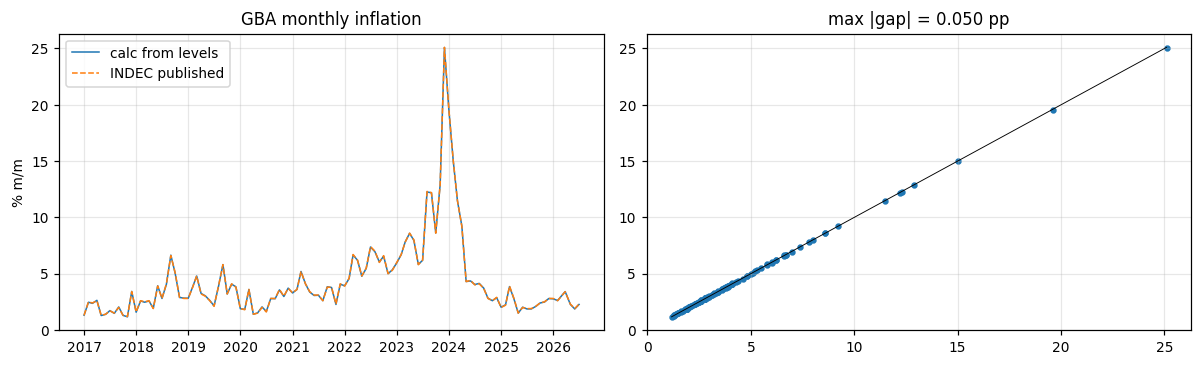

In [22]:
cc = cpi.dropna(subset=["infl_mom_gba", "indec_mom_gba_pct"]).copy()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(cc.date, cc.infl_mom_gba, lw=1, label="calc from levels")
ax[0].plot(cc.date, cc.indec_mom_gba_pct, lw=1, ls="--", label="INDEC published")
ax[0].set_title("GBA monthly inflation"); ax[0].set_ylabel("% m/m"); ax[0].legend()
ax[1].scatter(cc.indec_mom_gba_pct, cc.infl_mom_gba, s=10)
lims = [cc[["indec_mom_gba_pct", "infl_mom_gba"]].min().min(),
        cc[["indec_mom_gba_pct", "infl_mom_gba"]].max().max()]
ax[1].plot(lims, lims, "k-", lw=.6)
ax[1].set_title(f"max |gap| = {(cc.infl_mom_gba - cc.indec_mom_gba_pct).abs().max():.3f} pp")
fig.tight_layout(); fig.savefig(C.OUT_FIG / "03_indec_crosscheck.png"); plt.show()

## D3 · Composite Total vs its components (sanity)

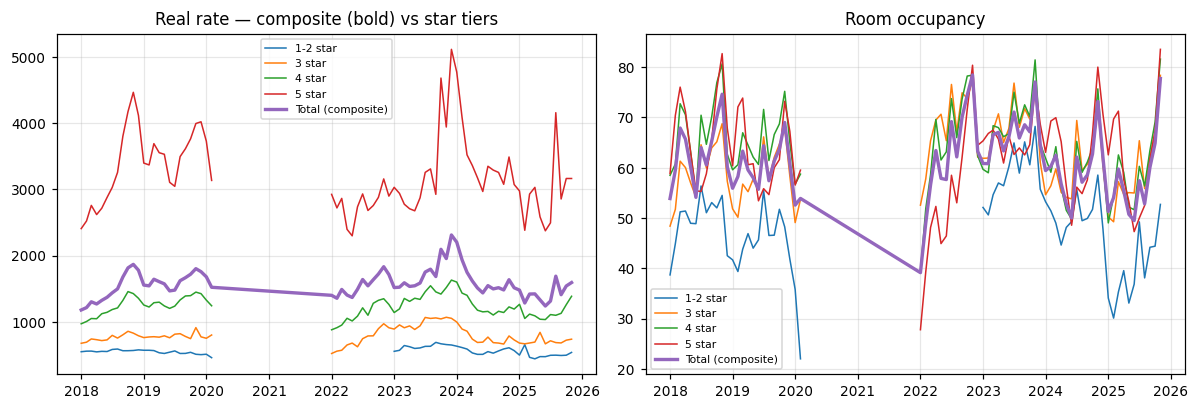

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for cat in C.CORE_CATEGORIES + [C.COMPOSITE_TOTAL]:
    s = wide[(wide.hotel_category == cat) & (wide.in_window == 1)].sort_values("date")
    lw = 2.2 if cat == C.COMPOSITE_TOTAL else 1
    ax[0].plot(s.date, s.real_rate_gba, lw=lw, label=C.CATEGORY_LABELS[cat])
    ax[1].plot(s.date, s.room_occupancy, lw=lw, label=C.CATEGORY_LABELS[cat])
ax[0].set_title("Real rate — composite (bold) vs star tiers"); ax[0].legend(fontsize=7)
ax[1].set_title("Room occupancy"); ax[1].legend(fontsize=7)
fig.tight_layout(); fig.savefig(C.OUT_FIG / "03_composite_check.png"); plt.show()

In [24]:
LOG.flush()
print("03_merge complete.")

03_merge complete.
